In [1]:
import ExTRA as ex
import numpy as np
import astroquery
import astropy
import matplotlib.pyplot as plt

ExTRA  imported correctly


## This notebook shows how to get a consistent single stellar model between gaia and hipparcos data.
## we propagate the single stellar model in cartesian coordinates when given a radial velocity in km/s as accurate as possible. This way the secular acceleration BETWEEN THE MODELS is eliminated
## After correcting the HIP data to be consistent with the gaia sss model we also remove the light travel time effect and shift the data accordingly in step 3. 

## Step 1:
## Correcting HIP to be consistent with Gaia given a radial velocity
### as for this example we use REAL HIP and GDR3 data of Nu Octantis

In [2]:
#Nu Oct as example
#HIP107089
hip_sss=np.array([5.6787539579,-1.3507009230,47.16,66.40,-239.10])
hip_iad,t_hip=ex.hip_read("data/nu_oct/HIP107089_esa.d")



In [3]:
gaia_asc=(21 +41/60 +28.5420355132/3600 )*15 #deg
gaia_dec=(-77 -23/60 -24.031541832/3600) #deg


gaia_sss=np.array([np.radians(gaia_asc),np.radians(gaia_dec),51.5172,68.656,-250.044]) # in radians for propagator

v_rad_gaia=34.4 #km/s


In [4]:
propagator=ex.EpochPropagation() #this class is able to propagate astrometry given v_rad and 2 standard epochs in julian YEARS

In [5]:
#Notice i give gaia model absolute position in RADIANS
#input of the propagator is [rad],[rad],[mas],[mas/yr],[mas/yr],[km/s],[yr],[yr]
gaia1991=np.array(propagator.propagate_astrometry(*gaia_sss,v_rad_gaia,1991.25,2016.0))
gaia1991_sss=gaia1991[:5]
print(gaia1991_sss)


[   5.67879677   -1.35074046   51.51488912   68.65904869 -250.01903991]


In [6]:
#this converts the last entry of the propagator back to the rv in km/s
def mur_to_vrad(mu_r,parallax):
    return mu_r*ex.astro_unit/ parallax
v_rad_1991=mur_to_vrad(gaia1991[-1],gaia1991[2])
print(v_rad_1991)




34.400742320783934


### Now that we have gaia1991, we can correct our hipparcos residuals to it, so models between HIP astrometric data and gaia astrometric data are correct.

In [7]:
gaia1991_sss_deg=gaia1991_sss.copy()
hip_sss_deg=hip_sss.copy()

#abs pos in degrees
gaia1991_sss_deg[:2]=np.degrees(gaia1991_sss[:2])
hip_sss_deg[:2]=np.degrees(hip_sss[:2])

#input of my abs res func is [deg],[deg],[mas],[mas/yr],[mas/yr]
abs_corrected=ex.abs_res(hip_iad[-2],gaia1991_sss_deg,hip_sss_deg,hip_iad)
hip_iad_corrected=hip_iad.copy()
hip_iad_corrected[-2]=abs_corrected

### the likelihood got worse as expected, since hipparcos on its own used to have the optimal fit with the data available. the now new residuals are consistent with gaias single steller solution and can therefor easily be fit in combination. the single stellar solution fit corrections can now be applied to both of the residuals in the same way

## Step 2: correcting secular acceleration in the time series data relative to their standard epochs

In [8]:
#i propagate astrometry between jyears, so i need to convert the hipparcos measurement times to julian year, same will have to be done to gaia
from astropy.time import Time
t_hip_jyear = Time(t_hip,format="jd").jyear

#actually the HIP measurement times are given in jyears relative to j1991.25. its easier to correct HIP than gaia since gaia will give JD timestamps
#Since i already compute the timestamps in julian days from the hip data, gaia as well as hip measurement times will have to be computed into julian year format relative to their respective standard epochs.
#this sounds complicated, but at the end of the day it will just be a one liner like above using astropy.time function.

In [34]:
(gaia_sss-gaia1991_sss)*25**2

array([ -0.02358669,   0.01875102,   1.44429794,  -1.9054319 ,
       -15.60005688])

In [10]:
x_sss,y_sss=ex.sss_model(gaia1991_sss_deg,t_hip,Sepoch=ex.J1991(),tangential=False)
x_sss=np.radians(ex.mas_to_deg(x_sss))
y_sss=np.radians(ex.mas_to_deg(y_sss))

In [11]:
shifts=[]
test=[]

for i,t in enumerate(t_hip_jyear):
    test.append(ex.EpochPropagation().propagate_astrometry(*gaia1991_sss,v_rad_1991,1991.25,t)[:2])
    delta=ex.EpochPropagation().propagate_astrometry(*gaia1991_sss,v_rad_1991,1991.25,t)[:2]-np.array([x_sss[i],y_sss[i]])
    #delta[0]=delta[0]*np.cos(delta[1])
    shifts.append(delta)
shifts=np.array(shifts)
test=np.array(test).T
#these are the shifts in asc and dec that need to be applied to the hip IAD

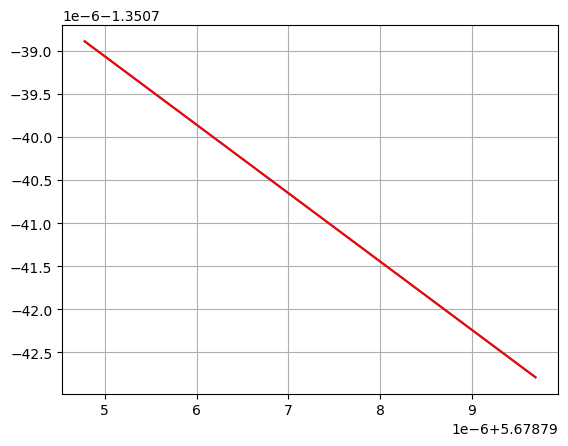

In [12]:
plt.plot(x_sss,y_sss,label="gaia model")

plt.plot(test[0],test[1],label="gaia model propagated to hip epochs",c="r")
plt.grid()
plt.show()

In [47]:
def secular_acceleration(vr_kms, parallax_mas,mu_mas_per_yr):
    
    # Scalar formula for secular acceleration

    A=9.7779222168e8 #mas km yr /s
    dot_mu_mas_per_yr2 = -2*vr_kms*parallax_mas*mu_mas_per_yr /A

    if abs(dot_mu_mas_per_yr2)> 0.02/(25**2):
        print("relevant!")
    
    return dot_mu_mas_per_yr2 # in mas/yr^2

In [13]:
sum(abs(x_sss-test[0]))
#np.float64(5.464864116788704e-10)

np.float64(2.7479174491418235e-10)

In [14]:
x_shift,y_shift=shifts.T
abs_corrected_shifted=hip_iad_corrected[-2]-(hip_iad[0]*x_shift[0]+hip_iad[1]*y_shift[1])
hip_iad_corrected_v2=hip_iad.copy()
hip_iad_corrected_v2[-2]=abs_corrected_shifted

## Step 3: correcting light time travel effect

In [15]:
ex.EpochPropagation().propagate_astrometry(*gaia1991_sss,v_rad_1991,1991.25,measurement)[:2]

NameError: name 'measurement' is not defined

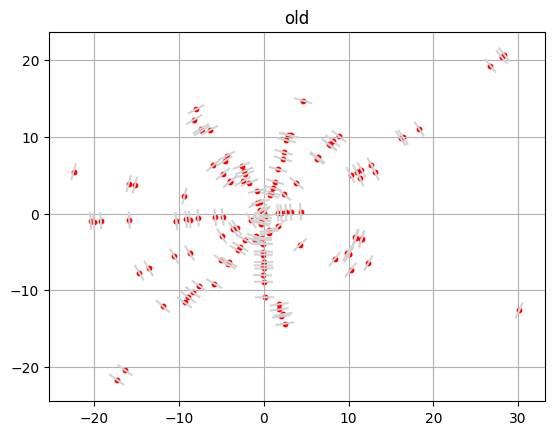

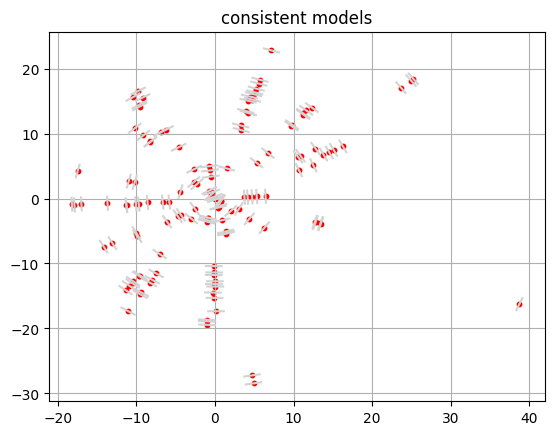

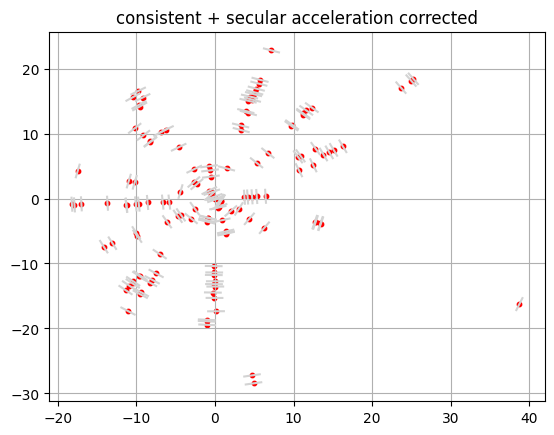

NameError: name 'hip_iad_corrected_v3' is not defined

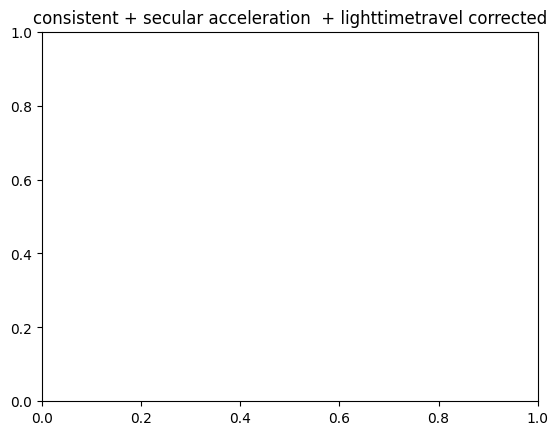

In [ ]:
ex.plot_hip(*ex.hip_2d(hip_iad))
plt.title("old")
plt.grid()
plt.show()

plt.title("consistent models")
ex.plot_hip(*ex.hip_2d(hip_iad_corrected))
plt.grid()
plt.show()


plt.title("consistent + secular acceleration corrected")
ex.plot_hip(*ex.hip_2d(hip_iad_corrected_v2))
plt.grid()
plt.show()

plt.title("consistent + secular acceleration  + lighttimetravel corrected")
ex.plot_hip(*ex.hip_2d(hip_iad_corrected_v3))
plt.grid()
plt.show()



In [ ]:
print("old likelihood:",ex.loglikelihood(hip_iad[-2],hip_iad[-1],0))
print("consistent models likelihood:",ex.loglikelihood(hip_iad_corrected[-2],hip_iad[-1],0))
print("corrected for secular acceleration likelihood:",ex.loglikelihood(hip_iad_corrected_v2,hip_iad[-1],0))
print("corrected for secular acceleration likelihood:",ex.loglikelihood(hip_iad_corrected_v3,hip_iad[-1],0))

old likelihood: 530.8247862687826
consistent models likelihood: 555.4981950746611
corrected for secular acceleration likelihood: 569.3213946399931
